# L2 Norm Visualization

Model 2 (M2-channel aware) mathematically shifts the intrinsic token energy compared to Model 1 (M1-channel unaware).

Loaded 983 sentences.


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

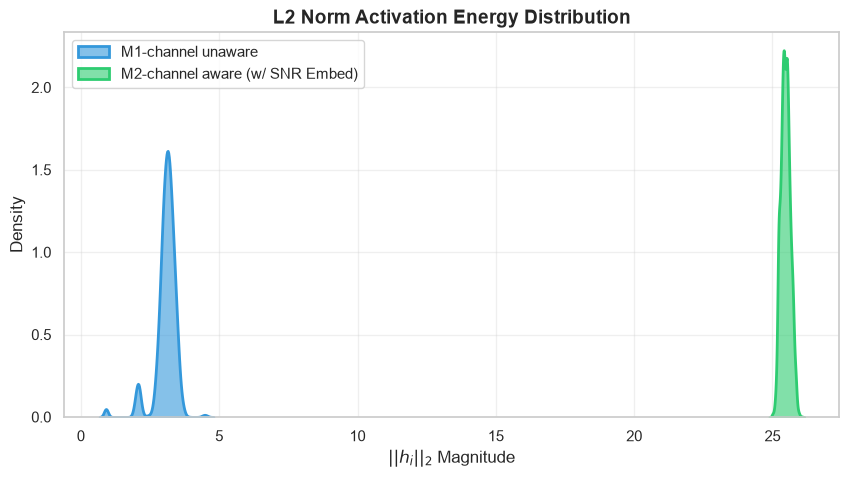

M1-channel unaware Mean L2 Norm: 3.07
M2-channel aware Mean L2 Norm: 25.46


In [4]:

import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
sys.path.append(os.path.abspath(r'C:\Users\Shrish\Desktop\semantic-comm\actual_project'))
from src.data_loader import EuroparlDataLoader
from src.llm_model import GenerativeSemanticModel
from src.llm_model_2 import AdvancedGenerativeSemanticModel
from transformers import T5Tokenizer

sns.set_theme(style="whitegrid", palette="muted")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = T5Tokenizer.from_pretrained("t5-small", local_files_only=True)

data_dir = r"C:\Users\Shrish\Desktop\semantic-comm\Semantic_Communication\europarl\en\en"
loader = EuroparlDataLoader(data_dir=data_dir, target_sentences=1000)
loader.scan_and_load()
sentences = loader.all_sentences[:1000]
print(f"Loaded {len(sentences)} sentences.")


model1 = GenerativeSemanticModel(model_name="t5-small", snr_db=5.0).to(device)
model1_path = os.path.abspath(r"C:\Users\Shrish\Desktop\semantic-comm\actual_project\models\t5_semantic.pt")
if os.path.exists(model1_path): model1.load_state_dict(torch.load(model1_path, map_location=device, weights_only=True))

model2 = AdvancedGenerativeSemanticModel(model_name="t5-small", snr_db=5.0).to(device)
model2_path = os.path.abspath(r"C:\Users\Shrish\Desktop\semantic-comm\actual_project\models\t5_semantic_advanced.pt")
if os.path.exists(model2_path): model2.load_state_dict(torch.load(model2_path, map_location=device, weights_only=True))

model1.eval()
model2.eval()

m1_norms = []
m2_norms = []
m1_raw = []
m2_raw = []

with torch.no_grad():
    for sent in sentences[:200]:
        inputs = tokenizer(sent, return_tensors="pt", max_length=20, padding="max_length", truncation=True).to(device)
        h1 = model1.t5.encoder(input_ids=inputs["input_ids"], attention_mask=inputs["attention_mask"], return_dict=True).last_hidden_state.squeeze(0)
        h2_pristine = model2.t5.encoder(input_ids=inputs["input_ids"], attention_mask=inputs["attention_mask"], return_dict=True).last_hidden_state.squeeze(0)
        snr_tensor = model2._get_snr_tensor(1, device, 5.0)
        h2 = h2_pristine + model2.snr_embed(snr_tensor).squeeze(0)
        
        m1_raw.append(h1)
        m2_raw.append(h2)
        m1_norms.extend(torch.norm(h1, p=2, dim=1).cpu().numpy())
        m2_norms.extend(torch.norm(h2, p=2, dim=1).cpu().numpy())

m1_raw_tensor = torch.cat(m1_raw, dim=0)
m2_raw_tensor = torch.cat(m2_raw, dim=0)

plt.figure(figsize=(10, 5))
sns.kdeplot(m1_norms, fill=True, color="#3498db", label="M1-channel unaware", alpha=0.6, lw=2)
sns.kdeplot(m2_norms, fill=True, color="#2ecc71", label="M2-channel aware (w/ SNR Embed)", alpha=0.6, lw=2)
plt.title("L2 Norm Activation Energy Distribution", fontsize=14, fontweight='bold')
plt.xlabel("$||h_i||_2$ Magnitude", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"M1-channel unaware Mean L2 Norm: {np.mean(m1_norms):.2f}")
print(f"M2-channel aware Mean L2 Norm: {np.mean(m2_norms):.2f}")

### Geometric Sphere Mapping
To prove that the manifold exists as a tight geometric shell, we project the 512-dimensional vectors down to 3D. the tokens lie on a uniform hypersphere surface corresponding to their L2 norm radius

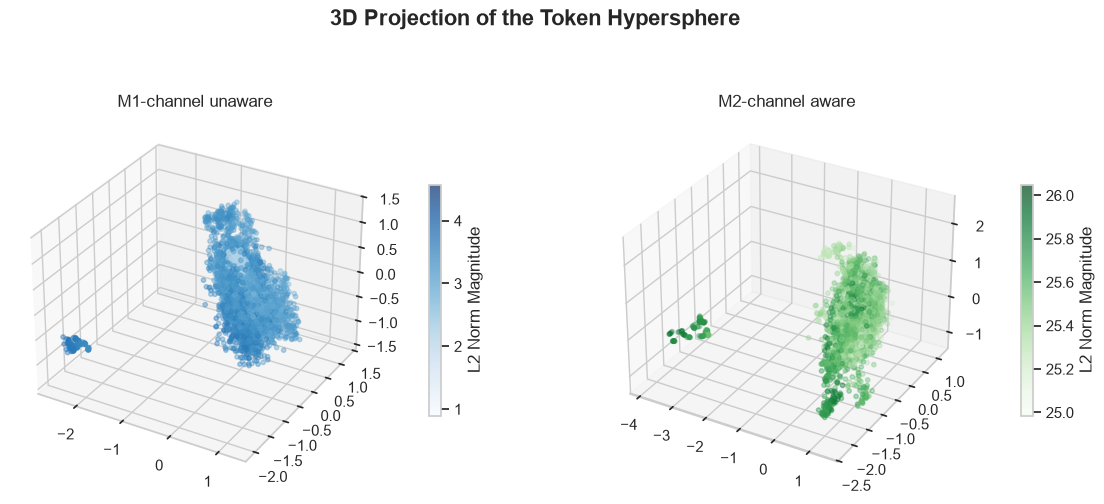

In [6]:
pca = PCA(n_components=3)
m1_3d = pca.fit_transform(m1_raw_tensor.cpu().numpy())
m2_3d = pca.fit_transform(m2_raw_tensor.cpu().numpy())

fig = plt.figure(figsize=(14, 6))
#m1
ax1 = fig.add_subplot(121, projection='3d')
sc1 = ax1.scatter(m1_3d[:, 0], m1_3d[:, 1], m1_3d[:, 2], c=m1_norms, cmap='Blues', s=10, alpha=0.7)
ax1.set_title("M1-channel unaware", fontsize=12)
fig.colorbar(sc1, ax=ax1, shrink=0.5, pad=0.1, label="L2 Norm Magnitude")

#m2
ax2 = fig.add_subplot(122, projection='3d')
sc2 = ax2.scatter(m2_3d[:, 0], m2_3d[:, 1], m2_3d[:, 2], c=m2_norms, cmap='Greens', s=10, alpha=0.7)
ax2.set_title("M2-channel aware", fontsize=12)
fig.colorbar(sc2, ax=ax2, shrink=0.5, pad=0.1, label="L2 Norm Magnitude")

plt.suptitle("3D Projection of the Token Hypersphere", fontsize=16, fontweight='bold')
plt.show()

### SNR Coordinate Translation Bias
If Model 2 simply translates the coordinate system without destroying internal structure, the variance of the L2 norms should remain stable while the mean drastically increases. run this cell only after training , snr embed layer se nhi chalega , illl update once i train

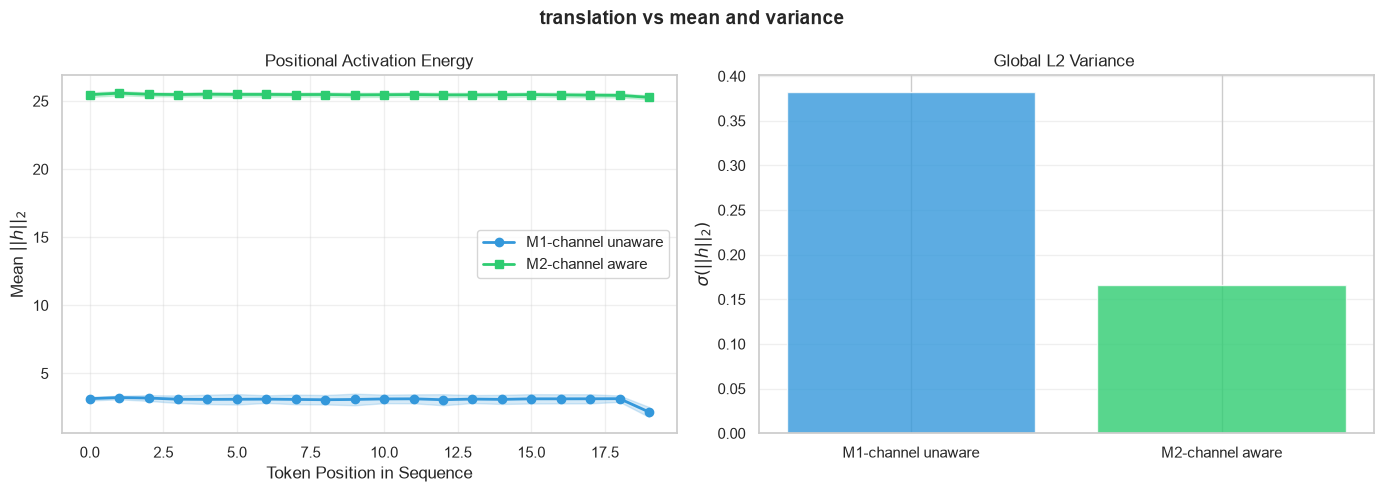

In [7]:
m1_reshaped = m1_raw_tensor.view(-1, 20, 512).cpu().numpy()
m2_reshaped = m2_raw_tensor.view(-1, 20, 512).cpu().numpy()

#mean
m1_pos_norms = np.linalg.norm(m1_reshaped, axis=2).mean(axis=0)
m2_pos_norms = np.linalg.norm(m2_reshaped, axis=2).mean(axis=0)

#var
m1_pos_std = np.linalg.norm(m1_reshaped, axis=2).std(axis=0)
m2_pos_std = np.linalg.norm(m2_reshaped, axis=2).std(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(20), m1_pos_norms, label='M1-channel unaware', color='#3498db', marker='o', lw=2)
axes[0].fill_between(range(20), m1_pos_norms - m1_pos_std, m1_pos_norms + m1_pos_std, color='#3498db', alpha=0.2)

axes[0].plot(range(20), m2_pos_norms, label='M2-channel aware', color='#2ecc71', marker='s', lw=2)
axes[0].fill_between(range(20), m2_pos_norms - m2_pos_std, m2_pos_norms + m2_pos_std, color='#2ecc71', alpha=0.2)

axes[0].set_title("Positional Activation Energy", fontsize=12)
axes[0].set_xlabel("Token Position in Sequence")
axes[0].set_ylabel("Mean $||h||_2$")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(['M1-channel unaware', 'M2-channel aware'], [np.std(m1_norms), np.std(m2_norms)], color=['#3498db', '#2ecc71'], alpha=0.8)
axes[1].set_title("Global L2 Variance ", fontsize=12)
axes[1].set_ylabel("$\sigma(||h||_2)$")
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle("translation vs mean and variance", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

